# Introduction

## Overview

A well-known dataset for image classification called CIFAR-10 contains 10,000 test images and 60,000 32x32 color training images that have been divided into 10 different categories. The categories are ship, truck, frog, horse, dog, deer, bird, cat, automobile, and automobile. With the use of this dataset, a machine learning model will be trained to identify and categorize the objects in the photos into these ten categories. Due to the small image size, few training samples, and presence of both large intra-class variations and inter-class similarities, this dataset poses a difficult image classification problem. Notwithstanding these difficulties, the CIFAR-10 dataset has received a lot of attention as a benchmark for comparing the effectiveness of different deep learning algorithms.

## Problem definition

The CIFAR-10 dataset is a challenging dataset for image recognition tasks due to its low resolution and high variability of objects within each class. The main problem we are trying to address in this project is to develop an accurate and efficient machine learning model that can classify images in the CIFAR-10 dataset with high precision and recall. It is challenging because the CIFAR-10 dataset is relatively small and contains low-resolution images, which makes it difficult for machine learning algorithms to learn the underlying patterns and features.

To address this problem, we will explore various machine learning techniques and evaluate their performance on the CIFAR-10 dataset. The ultimate goal is to develop a model that can accurately classify images in the CIFAR-10 dataset with high precision and recall, and generalize well to new images.

## Choosing a measure of success

To evaluate the performance of our machine learning model for image recognition on the CIFAR-10 dataset, we will use several commonly used metrics, namely accuracy, score, precision, recall, and AUC.

Accuracy is the proportion of correctly classified images to the total number of images in the dataset. It is a simple and intuitive metric that measures the overall performance of the model. A higher accuracy indicates better performance, but it may not be sufficient to capture the performance of the model in more detail.

Score is a metric used in machine learning models that assign a probability to each class for a given image. It measures the confidence of the model in its predictions. A higher score indicates higher confidence in the prediction.

Precision and recall are measures that capture the performance of the model in identifying each class separately. Precision measures the proportion of correctly classified images of a given class to the total number of images classified as that class. Recall measures the proportion of correctly classified images of a given class to the total number of images that actually belong to that class. A higher precision indicates fewer false positives, while a higher recall indicates fewer false negatives.

AUC (Area Under the Curve) is a metric commonly used in binary classification problems, which measures the overall performance of the model across different probability thresholds. It is a useful metric for comparing the performance of different models, even when the class distribution is imbalanced.

Using these metrics, we can evaluate the performance of our machine learning model in different aspects and determine which aspects require improvement. For example, a model with high accuracy but low recall for a particular class may need to be adjusted to better identify that class. By considering multiple metrics, we can obtain a more complete and nuanced understanding of the performance of our model on the CIFAR-10 dataset.

## Deciding an evaluation protocol

To evaluate the performance of our machine learning model on the CIFAR-10 dataset, we will follow a standard protocol that involves the following steps:

- Data Preprocessing: We will first preprocess the data by flattening and normalizing the pixel values. We will also perform one hot encoding. This will help us to increase the variability of the data and prevent overfitting.
- Model Selection: We will experiment with various machine learning algorithms such as adding drop out layers, integrating L2 regularisations, as well as implementing early stopping to find the best performing model.
- Hyperparameter Tuning: We will fine-tune the hyperparameters of the selected model using techniques such as grid search to optimize its performance.
- Cross-Validation: We will use k-fold cross-validation to assess the performance of the model on the training data. This involves splitting the data into k subsets, training the model on k-1 subsets, and testing it on the remaining subset. We will repeat this process k times, each time using a different subset as the test set. This will help us to get a more accurate estimate of the model's performance and reduce the risk of overfitting.
- Model Evaluation: We will evaluate the performance of the model on the test data using the metrics described earlier, such as accuracy, score, precision, recall, and AUC.
- Analysis and Interpretation: We will analyze the results and interpret the performance of the model in light of the metrics and evaluation criteria. We will also compare the performance of our model with the state-of-the-art models on the CIFAR-10 dataset to understand the strengths and weaknesses of our approach.

By following this protocol, we will be able to evaluate the performance of our machine learning model on the CIFAR-10 dataset in a rigorous and systematic way. This will enable us to identify the strengths and weaknesses of our approach and improve its performance.

# Data Collection and Preparation

## Import libraries

In [1]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from skimage.transform import resize

import tensorflow as tf
import tensorflow_datasets as tfds

from keras import regularizers
from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.optimizers import RMSprop

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import itertools

## Assembling the dataset

In [2]:
# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

In [3]:
# Print the shape of the dataset
print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape:", x_test.shape)
print("Testing labels shape:", y_test.shape)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)


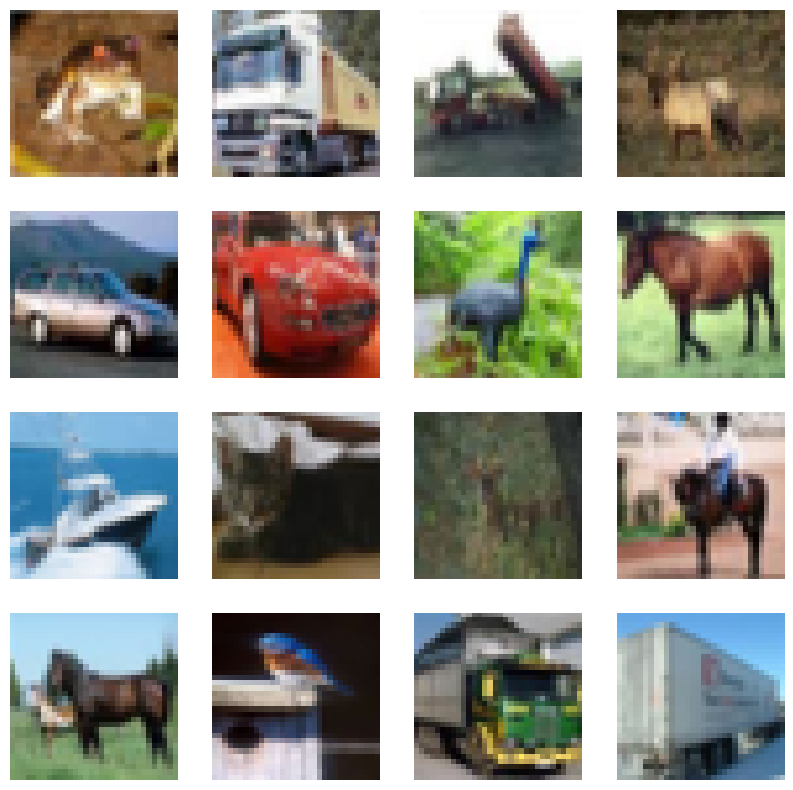

In [4]:
# Plot the first 16 images in the training set
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axs.flat):
    ax.imshow(x_train[i])
    ax.axis('off')

plt.show()

# Data Preprocessing

## Resizing the image

When working with image datasets, we often want to ensure that all images in the dataset are the same size. This is important because many machine learning algorithms require fixed input dimensions. By resizing all images to the same size, we can ensure that our data is consistent and ready for processing.

In [5]:
# Resize images
RESIZE = (16, 16)
x_train_resized = []
for entry in x_train:
    image_resized = resize(entry, RESIZE, anti_aliasing=True)
    x_train_resized.append(image_resized)
x_train_resized = np.array(x_train_resized)

x_test_resized = []
for entry in x_test:
    image_resized = resize(entry, RESIZE, anti_aliasing=True)
    x_test_resized.append(image_resized)
x_test_resized = np.array(x_test_resized)

## Flattening the image

Some machine learning algorithms require that input data is in the form of a 1-dimensional vector rather than a 2-dimensional image. Flattening the image by converting it from a 2D array to a 1D array of pixel values can help us achieve this.

In [6]:
# Flatten images
x_train_flat = x_train_resized.reshape(x_train_resized.shape[0], -1)
x_test_flat = x_test_resized.reshape(x_test_resized.shape[0], -1)

## Normalising the data

Normalization is an important preprocessing step that is performed to ensure that all the features in a dataset are on a similar scale. This is done to prevent certain features from dominating others, which can lead to biased results during training.

In [7]:
# Normalise data
scaler = StandardScaler()
x_train_norm = scaler.fit_transform(x_train_flat)
x_test_norm = scaler.transform(x_test_flat)

## One hot encoding

One hot encoding is a technique used to transform categorical data (e.g. labels) into numerical data that can be used for training machine learning models. This is done to ensure that the model can learn from the data without assigning arbitrary numerical values to the categories.

In [8]:
# One-hot encoding of labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.fit_transform(y_test)

onehot_encoder = OneHotEncoder(sparse=False)
y_train_onehot = onehot_encoder.fit_transform(y_train_encoded.reshape(-1, 1))
y_test_onehot = onehot_encoder.fit_transform(y_test_encoded.reshape(-1, 1))

/opt/anaconda3/envs/tensorflow/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/tensorflow/lib/python3.10/site-packages/sklearn/preprocessing/_label.py:116: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/tensorflow/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/opt/anaconda3/envs/tensorflow/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:828: FutureWarning: `sparse` was renamed to

In [9]:
# Print the shapes of the datasets
print("Training data shape:", x_train_norm.shape)
print("Training labels shape:", y_train_onehot.shape)
print("Testing data shape:", x_test_norm.shape)
print("Testing labels shape:", y_test_onehot.shape)

Training data shape: (50000, 768)
Training labels shape: (50000, 10)
Testing data shape: (10000, 768)
Testing labels shape: (10000, 10)


# Model Training

## Developing a model that does better than the baseline

I am developing a deep learning model for the CIFAR-10 dataset that I expect to perform better than the baseline accuracy. The baseline accuracy for the CIFAR-10 dataset is approximately 10%, which represents the performance of a simple model that predicts the most frequent class. My model incorporates advanced techniques such as dropout, regularization, and early stopping to improve its accuracy and avoid overfitting. I am using grid search and k-fold cross validation to evaluate the model's performance on unseen data, and I aim to achieve an accuracy that surpasses the baseline by a significant margin.

In [10]:
def deep_neural_network(hidden_layers = 0, hidden_neurons = np.nan, activation = None,
                        dropout = np.nan, input_dimension = 2, output_dimension = 1,
                        optimizer = 'rmsprop', loss = 'binary_crossentropy', metrics = ['accuracy'],
                        name = None):
    """
    Constructs a deep neural network model with specified number of hidden layers, hidden neurons,
    activation function, dropout rate, input and output dimensions, optimizer, loss function and metrics.
    The model can be given a name for better identification.
    
    Parameters:
        hidden_layers (int): Number of hidden layers in the model.
        hidden_neurons (int or np.nan): Number of neurons in each hidden layer. If np.nan, the value
            is not specified and must be defined in each layer.
        activation (str or None): Activation function to be used in each layer. If None, linear
            activation is used.
        dropout (float or np.nan): Dropout rate to be used in each layer. If np.nan, no dropout is used.
        input_dimension (int): Number of features in the input layer.
        output_dimension (int): Number of classes in the output layer.
        optimizer (str): Optimizer to be used for training the model.
        loss (str): Loss function to be used during training.
        metrics (list): Metrics to be used for evaluating the model.
        name (str or None): Optional name for the model.
    
    Returns:
        keras.Sequential: Compiled deep neural network model.
    """
    
    # Initialize an empty Sequential model
    model = Sequential()
    
    # Loop through the specified number of hidden layers and add them to the model
    for layer in range(hidden_layers):
        
        # Add a Dense layer with the specified number of neurons and activation function
        model.add(Dense(hidden_neurons, 
                  activation = activation, 
                  input_shape = 'default' if layer > 1 else (input_dimension,)))
        
        # Add a Dropout layer with the specified dropout rate (if specified)
        if ~np.isnan(dropout) :
            model.add(Dropout(dropout))
        
    # Add the output layer with the specified number of classes and activation function
    model.add(Dense(output_dimension, 
                    activation = 'sigmoid' if output_dimension == 1 else 'softmax',
                    input_shape = 'default' if hidden_layers > 0 else (input_dimension,)))
  
    # Assign a name to the model (if specified)
    if name is not None :
        model._name = name
        
    # Compile the model with the specified optimizer, loss function, and metrics
    model.compile(optimizer = optimizer, loss = loss, metrics = metrics)
    
    # Return the compiled model
    return model

In [11]:
# Fitting MLP Classification Model
def train_deep_neural_network(model, X, y,
                              batch_size = 32, epochs = 100, 
                              val_data = None, callbacks = [], seed = 0) :
    """
    Train a deep neural network model for classification.

    Parameters:
    model (Keras Sequential model): the neural network model to be trained
    X (array-like): the input features
    y (array-like): the target variable
    batch_size (int): number of samples per gradient update
    epochs (int): number of epochs to train the model
    val_data (tuple): optional validation data as a tuple of input and target arrays
    callbacks (list): list of Keras callback objects
    seed (int): random seed for reproducibility

    Returns:
    dict: a dictionary containing the trained model, validation score, and training history
    """

    # Split the data into training and validation sets
    if val_data is None :
        X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, 
                                                          random_state = seed, shuffle = True, 
                                                          stratify = y)
        
    else :
        X_train, y_train, X_val, y_val = X, y, val_data[0], val_data[1]
  

    # Train the model
    history = model.fit(X_train, y_train,
                        batch_size = batch_size, epochs = epochs, 
                        validation_data = (X_val, y_val),
                        callbacks = callbacks,
                        verbose = 0)

    # Return the trained model, validation score, and training history
    return {'model': model, 
            'val_score': model.evaluate(X_val, y_val, verbose = 0)[1:], 
            'history': history}

In [12]:
INPUT_DIMENSION = x_train_norm.shape[1]
OUTPUT_CLASSES = y_train_onehot.shape[1]
OPTIMIZER = 'RMSprop'
LOSS_FUNC = 'categorical_crossentropy'
METRICS = ['categorical_accuracy', 
           tf.keras.metrics.Precision(name = 'precision'), 
           tf.keras.metrics.Recall(name = 'recall'),
           tf.keras.metrics.AUC(name = 'auc', multi_label = True)]

Metal device set to: Apple M2


2023-03-03 22:03:22.265160: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-03-03 22:03:22.265178: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


## Scaling up: developing a model that overfits

In [13]:
learning_rate = 0.01

overfitted_model = deep_neural_network(hidden_layers = 1, 
                                       hidden_neurons = 8,
                                       activation = 'relu',
                                       input_dimension = INPUT_DIMENSION,
                                       output_dimension = OUTPUT_CLASSES,
                                       optimizer = RMSprop(learning_rate = learning_rate),
                                       loss = LOSS_FUNC,
                                       metrics = METRICS,
                                       name = 'Overfitted')

overfitted_model.summary()

Model: "Overfitted"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 8)                 6152      
                                                                 
 dense_1 (Dense)             (None, 10)                90        
                                                                 
Total params: 6,242
Trainable params: 6,242
Non-trainable params: 0
_________________________________________________________________


# Model Evaluation

## Defining evaluation functions

In [14]:
# Define a function that plots training history, with default monitors of 'loss' and 'AUC'
def plot_training_history(history, monitors=['loss', 'AUC']) :

    # Create a figure with two subplots, and share the x-axis between them
    fig, axs = plt.subplots(1, 2, sharex='all', figsize=(15,5))
 
    # Iterate through the subplots and monitors, and plot the corresponding training and validation data
    for ax, monitor in zip(axs.flat, monitors) :
        loss, val_loss = history.history[monitor], history.history['val_' + monitor]

        # If the monitor is 'loss', change its name to 'Loss' for better formatting
        if monitor == 'loss' :
            monitor = monitor.capitalize()

        # Define the x-axis range as the number of epochs
        epochs = range(1, len(loss)+1)

        # Plot the training and validation data for the current monitor
        ax.plot(epochs, loss, 'b.', label = monitor)
        ax.plot(epochs, val_loss, 'r.', label = 'Validation ' + monitor)

        # Set the x-axis limits, subplot title, and axis labels
        ax.set_xlim([0, len(loss)])
        ax.title.set_text('Training and Validation ' + monitor + 's')
        ax.set_xlabel('Epochs')
        ax.set_ylabel(monitor)

        # Add a legend and grid to the subplot
        ax.legend()
        ax.grid()

    # Display the plot
    _ = plt.show()

## Evaluating the overfitted model

In [15]:
batch_size = 256
EPOCHS = 30

trained_overfitted_model = train_deep_neural_network(overfitted_model, x_train_norm, y_train_onehot,
                                                      batch_size = batch_size, epochs = EPOCHS, 
                                                      val_data = (x_test_norm, y_test_onehot), 
                                                      callbacks = [])

2023-03-03 22:03:22.445950: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2023-03-03 22:03:22.845010: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:03:25.086262: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


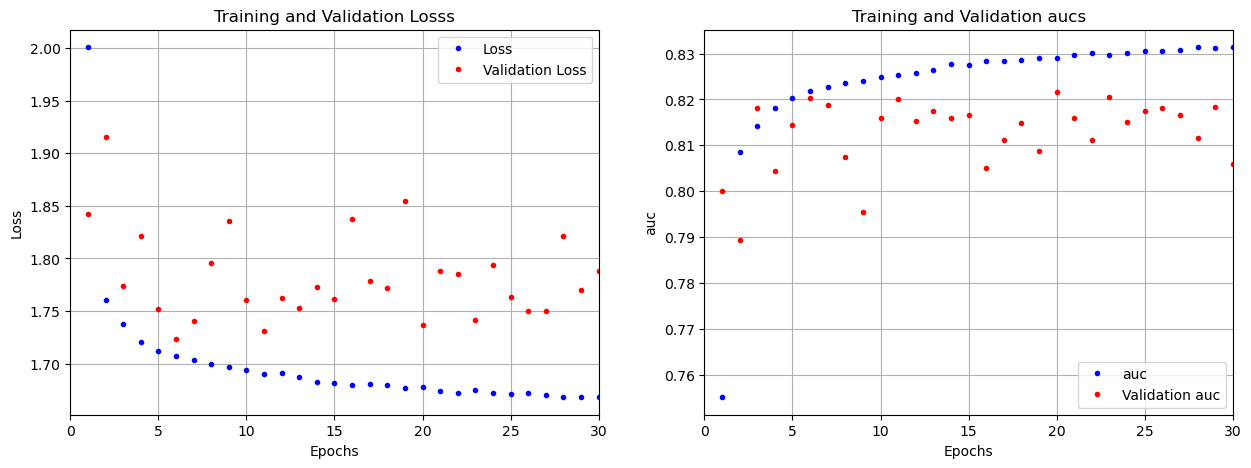

In [16]:
plot_training_history(trained_overfitted_model['history'], monitors = ['loss', 'auc'])

In [17]:
print('Accuracy (Validation): {:.2f} (baseline={:.2f})'.format(trained_overfitted_model['val_score'][0], 0.1))
print('Precision (Validation): {:.2f}'.format(trained_overfitted_model['val_score'][1]))
print('Recall (Validation): {:.2f}'.format(trained_overfitted_model['val_score'][2]))
print('AUC (Validation): {:.2f}'.format(trained_overfitted_model['val_score'][3]))

Accuracy (Validation): 0.34 (baseline=0.10)
Precision (Validation): 0.53
Recall (Validation): 0.13
AUC (Validation): 0.81


# Model Tuning

## Drop out layers

### Overview

Dropout is a regularization technique used in neural networks to prevent overfitting. It works by randomly dropping out (i.e., setting to zero) a number of output features of a layer during the training phase. This has the effect of forcing the neural network to learn more robust features that are useful in conjunction with many different subsets of the other neurons. Dropout can be thought of as training multiple models in parallel, each of which learns to handle a different portion of the training data. By doing so, dropout improves the generalization and accuracy of the model on the test data.

### Creating the model

In [18]:
learning_rate = 0.01

dropout_model = deep_neural_network(hidden_layers = 3, 
                                    hidden_neurons = 8,
                                    activation = 'relu',
                                    dropout = 0.4,
                                    input_dimension = INPUT_DIMENSION,
                                    output_dimension = OUTPUT_CLASSES,
                                    optimizer = RMSprop(learning_rate = learning_rate),
                                    loss = LOSS_FUNC,
                                    metrics = METRICS,
                                    name = 'Drop_Out')

dropout_model.summary()

Model: "Drop_Out"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 8)                 6152      
                                                                 
 dropout (Dropout)           (None, 8)                 0         
                                                                 
 dense_3 (Dense)             (None, 8)                 72        
                                                                 
 dropout_1 (Dropout)         (None, 8)                 0         
                                                                 
 dense_4 (Dense)             (None, 8)                 72        
                                                                 
 dropout_2 (Dropout)         (None, 8)                 0         
                                                                 
 dense_5 (Dense)             (None, 10)                90 

In [19]:
batch_size = 256
EPOCHS = 30

trained_dropout_model = train_deep_neural_network(dropout_model, x_train_norm, y_train_onehot,
                                                  batch_size = batch_size, epochs = EPOCHS, 
                                                  val_data = (x_test_norm, y_test_onehot), 
                                                  callbacks = [])

2023-03-03 22:04:30.335127: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:04:33.100332: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


### Evaluating the model

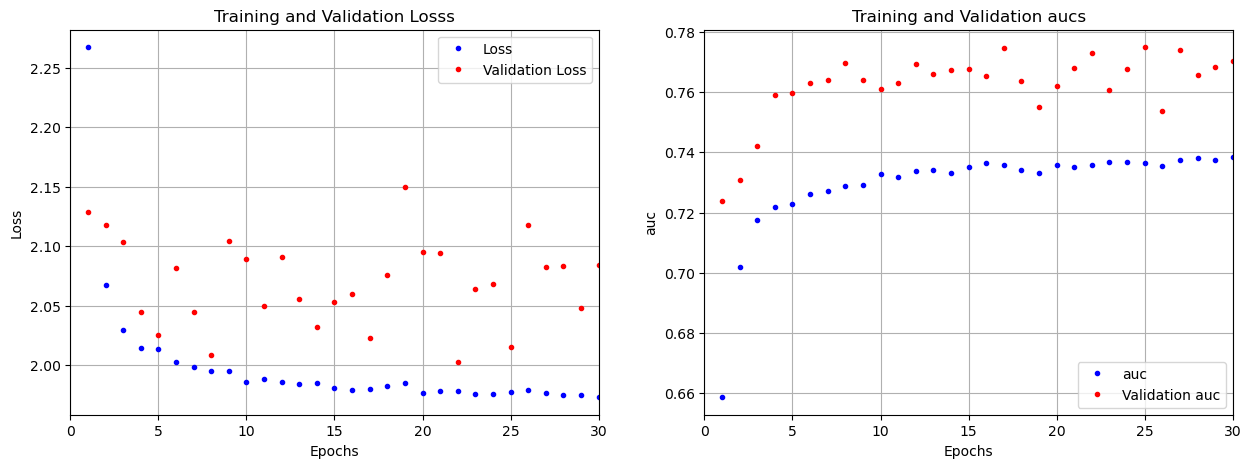

In [20]:
plot_training_history(trained_dropout_model['history'], monitors = ['loss', 'auc'])

In [21]:
print('Accuracy (Validation): {:.2f} (baseline={:.2f})'.format(trained_dropout_model['val_score'][0], 0.1))
print('Precision (Validation): {:.2f}'.format(trained_dropout_model['val_score'][1]))
print('Recall (Validation): {:.2f}'.format(trained_dropout_model['val_score'][2]))
print('AUC (Validation): {:.2f}'.format(trained_dropout_model['val_score'][3]))

Accuracy (Validation): 0.25 (baseline=0.10)
Precision (Validation): 0.00
Recall (Validation): 0.00
AUC (Validation): 0.77


## Regularising the model

### Overview

L2 regularization is a technique used to prevent overfitting in machine learning models by adding a penalty term to the loss function that is proportional to the squared magnitude of the model weights. This penalty term encourages the model to have smaller weights, reducing the complexity of the model and preventing it from fitting the noise in the training data.

By using L2 regularization, a model can improve its accuracy on both the training and test data sets by preventing overfitting. Specifically, the regularization term adds a bias to the cost function that causes the model to prefer solutions with smaller weights, effectively reducing the complexity of the model and improving its generalization performance. The regularization term controls the trade-off between fitting the training data well and keeping the model simple, leading to a better balance between underfitting and overfitting.

### Creating the model

In [22]:
# Define L2 regularization strength
l2_lambda = 0.01

l2r_model = deep_neural_network(hidden_layers=3, 
                                hidden_neurons=8,
                                activation='relu',
                                dropout=0,
                                input_dimension=INPUT_DIMENSION,
                                output_dimension=OUTPUT_CLASSES,
                                optimizer=RMSprop(learning_rate=learning_rate),
                                loss=LOSS_FUNC,
                                metrics=METRICS,
                                name='L2_Regularisation')

# Add L2 regularization to each Dense layer
for layer in l2r_model.layers:
    if isinstance(layer, Dense):
        layer.kernel_regularizer = regularizers.l2(l2_lambda)

l2r_model.summary()

Model: "L2_Regularisation"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_6 (Dense)             (None, 8)                 6152      
                                                                 
 dropout_3 (Dropout)         (None, 8)                 0         
                                                                 
 dense_7 (Dense)             (None, 8)                 72        
                                                                 
 dropout_4 (Dropout)         (None, 8)                 0         
                                                                 
 dense_8 (Dense)             (None, 8)                 72        
                                                                 
 dropout_5 (Dropout)         (None, 8)                 0         
                                                                 
 dense_9 (Dense)             (None, 10)          

### Evaluating the model

In [23]:
batch_size = 128
EPOCHS = 50

trained_l2r_model = train_deep_neural_network(l2r_model, x_train_norm, y_train_onehot,
                                              batch_size = batch_size, epochs = EPOCHS, 
                                              val_data = (x_test_norm, y_test_onehot), 
                                              callbacks = [])

2023-03-03 22:05:54.211533: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:05:59.103626: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


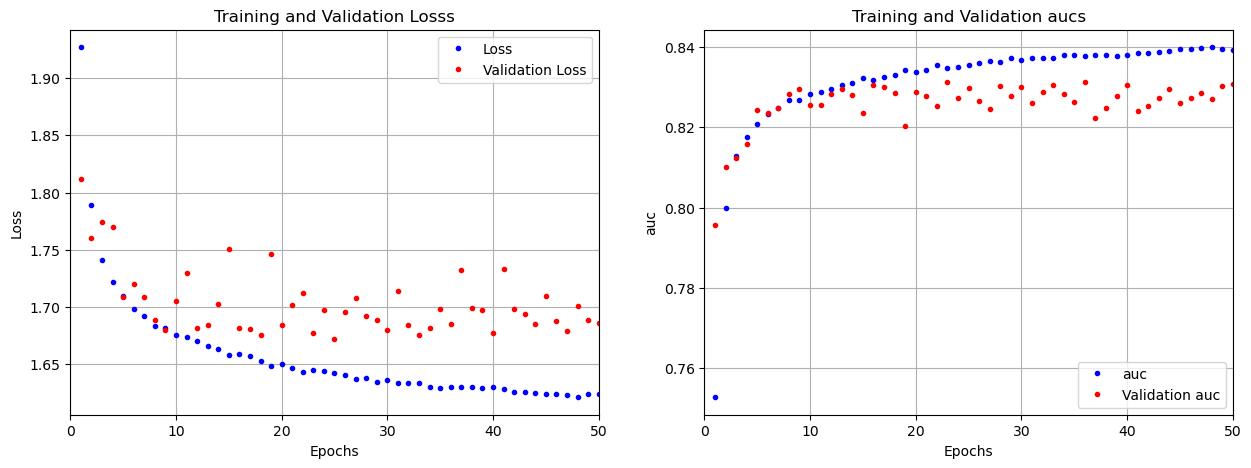

In [24]:
plot_training_history(trained_l2r_model['history'], monitors = ['loss', 'auc'])

In [25]:
print('Accuracy (Validation): {:.2f} (baseline={:.2f})'.format(trained_l2r_model['val_score'][0], 0.1))
print('Precision (Validation): {:.2f}'.format(trained_l2r_model['val_score'][1]))
print('Recall (Validation): {:.2f}'.format(trained_l2r_model['val_score'][2]))
print('AUC (Validation): {:.2f}'.format(trained_l2r_model['val_score'][3]))

Accuracy (Validation): 0.39 (baseline=0.10)
Precision (Validation): 0.57
Recall (Validation): 0.18
AUC (Validation): 0.83


## Early stopping

### Overview

Early stopping is a technique used in machine learning to prevent overfitting and improve the accuracy of a model during training. It involves monitoring the performance of the model on a validation set during training and stopping the training process when the performance of the model on the validation set starts to degrade. This is done by setting a certain threshold for the performance metric on the validation set, such as accuracy or loss. When the performance of the model fails to improve beyond the threshold, the training process is stopped. By stopping the training process early, early stopping prevents the model from overfitting to the training data and allows it to generalize better to new, unseen data, improving the accuracy of the model.

### Creating the model

In [26]:
early_stopping_model = deep_neural_network(hidden_layers=3, 
                                           hidden_neurons=8,
                                           activation='relu',
                                           dropout=0,
                                           input_dimension=INPUT_DIMENSION,
                                           output_dimension=OUTPUT_CLASSES,
                                           optimizer=RMSprop(learning_rate=learning_rate),
                                           loss=LOSS_FUNC,
                                           metrics=METRICS,
                                           name='Early_Stopping')

### Evaluating the model

In [27]:
batch_size = 256
EPOCHS = 50
MONITOR = 'val_loss'
PATIENCE = 10

EARLY_STOP = EarlyStopping(monitor=MONITOR, restore_best_weights=True, patience=PATIENCE, verbose=0)

trained_early_stopping_model = train_deep_neural_network(early_stopping_model, x_train_norm, y_train_onehot,
                                                         batch_size = batch_size, epochs = EPOCHS, 
                                                         val_data = (x_test_norm, y_test_onehot), 
                                                         callbacks = [EARLY_STOP])

2023-03-03 22:10:22.481628: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:10:25.531043: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


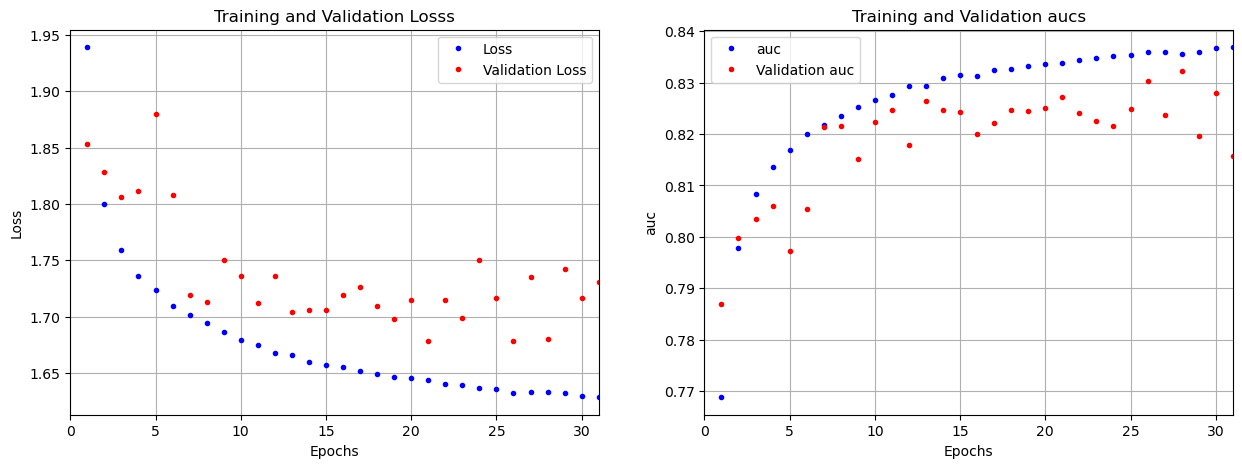

In [28]:
plot_training_history(trained_early_stopping_model['history'], monitors = ['loss', 'auc'])

In [29]:
print('Accuracy (Validation): {:.2f} (baseline={:.2f})'.format(trained_early_stopping_model['val_score'][0], 0.1))
print('Precision (Validation): {:.2f}'.format(trained_early_stopping_model['val_score'][1]))
print('Recall (Validation): {:.2f}'.format(trained_early_stopping_model['val_score'][2]))
print('AUC (Validation): {:.2f}'.format(trained_early_stopping_model['val_score'][3]))

Accuracy (Validation): 0.39 (baseline=0.10)
Precision (Validation): 0.63
Recall (Validation): 0.16
AUC (Validation): 0.83


## Tuning hyperparameters

### Overview

To optimize the performance of a machine learning model, it is important to select the best set of hyperparameters. In our approach, we use k-fold cross-validation and grid search to systematically evaluate and tune our model's hyperparameters.

K-fold cross-validation is a technique used to assess how well a model generalizes to new data. In this approach, we divide the dataset into k equally sized folds, where k-1 folds are used for training the model, and the remaining fold is used for testing. We repeat this process k times, with each fold being used once for testing. This enables us to obtain k estimates of model performance, which we can average to obtain a more reliable estimate of the model's generalization performance.

Grid search is a hyperparameter tuning technique that systematically searches for the optimal combination of hyperparameters by evaluating the model's performance over a predefined set of hyperparameters. In our approach, we define a grid of hyperparameters that we want to search over. We then train and evaluate our model using each combination of hyperparameters in the grid, and select the hyperparameters that yield the best performance.

To use k-fold cross-validation and grid search together, we perform grid search within each fold of the cross-validation process. This enables us to obtain k estimates of the model's performance for each combination of hyperparameters in the grid. We then average these k estimates to obtain a more reliable estimate of the model's performance for each combination of hyperparameters.

By using k-fold cross-validation and grid search, we can efficiently search the hyperparameter space and select the best hyperparameters for our model. This approach helps us to avoid overfitting, improves the generalization performance of our model, and enables us to obtain more reliable estimates of model performance.

### Creating the model

In [30]:
# Reformat Grid CV Stats to Dataframe
def to_dataframe(stats, mapping):
    entries = []
    
    # Loop over stats dictionary to get parameter values and metrics
    for param, metrics in stats.items():
        
        # Convert parameter string to dictionary format
        entry = eval(param)
        
        # Add metrics as key-value pairs to the parameter dictionary
        for key, value in metrics.items():
            entry[key] = value
        
        # Rename the metric keys to their desired names using the mapping dictionary
        for key, value in mapping.items():
            entry[value] = entry['scores'][key]
            
        # Remove the scores key from the parameter dictionary
        entry.pop('scores') 
        
        # Append the formatted entry to the list of entries
        entries.append(entry)
        
    # Convert the list of entries to a Pandas DataFrame and return it
    return pd.DataFrame(data=entries)

In [31]:
# Grid Search CV function
# X: input data
# y: target data
# space: dictionary of hyperparameter search space
# cv: number of cross-validation folds
# learning_rate: learning rate for optimizer
# loss: loss function to use for training
# metrics: evaluation metrics to use for training
# epochs: number of epochs for training
# callbacks: list of Keras callbacks to use for training
# seed: random seed for reproducibility
# order: dictionary specifying order of output columns in resulting DataFrame

def grid_search_cv(X, y,
                   space, cv, 
                   learning_rate, loss, metrics, 
                   epochs, callbacks=[], seed=0, 
                   order={}) :
    
    # Extract hyperparameter keys and values from search space dictionary
    keys, values = zip(*space.items())
    
    # Initialize dictionary to store results for each combination of hyperparameters
    stats = {}
    
    # Iterate over all combinations of hyperparameters
    for params in [dict(zip(keys, v)) for v in itertools.product(*values)]:
        
        # Initialize k-fold cross-validation with stratified sampling
        kfold = StratifiedKFold(n_splits=cv, shuffle=True, random_state=seed)
        
        # Initialize lists to store evaluation scores, number of epochs, and validation losses for each fold
        scores, stopped, losses = [], [], []
        
        # Iterate over all folds of cross-validation
        for train, validate in kfold.split(X, y.argmax(axis=1)):
            
            # Initialize deep neural network model with specified hyperparameters
            model = deep_neural_network(hidden_layers=params['hidden_layers'], 
                                        hidden_neurons=params['neurons'], 
                                        activation=params['activation'], 
                                        dropout=params['dropout'], 
                                        input_dimension=X.shape[1], 
                                        output_dimension=1 if len(y.shape)<2 else y.shape[1],
                                        optimizer=RMSprop(learning_rate=learning_rate), 
                                        loss=loss, metrics=metrics)
            
            # Add L2 regularization to each Dense layer
            for layer in model.layers:
                if isinstance(layer, Dense):
                    layer.kernel_regularizer = regularizers.l2(l2_lambda)
      
            # Train deep neural network model on training data
            trained = train_deep_neural_network(model, 
                                                X[train,:], y[train], 
                                                batch_size=params['batch_size'], epochs=epochs, 
                                                val_data=(X[validate,:], y[validate,:]), 
                                                callbacks=callbacks, seed=seed) 
            
            # Evaluate trained model on validation data
            evaluations = trained['model'].evaluate(X[validate,:], y[validate,:], verbose=0)[1:]
                        
            # Store evaluation scores, number of epochs, and validation loss for current fold
            scores.append(evaluations)
            stopped.append(len(trained['history'].history['val_loss']))
            losses.append(np.min(trained['history'].history['val_loss']))
        
        # Compute mean evaluation scores, number of epochs, and validation loss over all folds
        stats[str(params)] = {  'scores': np.mean(scores, axis=0), 
                                'epochs': np.mean(stopped), 
                                'val_loss': np.mean(losses) }
    
    # Convert results dictionary to DataFrame with specified column order
    return to_dataframe(stats, order)

In [32]:
orders = {
    0: 'categorical_accuracy',              
    1: 'precision',
    2: 'recall',
    3: 'auc',
}

In [33]:
KFOLDS = 5

In [34]:
params = {
    'hidden_layers': [2, 3],
    'neurons': [8],
    'activation': ['relu'],
    'dropout': [0.2, 0.4],
    'batch_size': [256, 516]
}

learning_rate = 0.01
EPOCHS = 30

stats = grid_search_cv(x_train_norm, y_train_onehot,  
                       space=params, cv=KFOLDS, 
                       learning_rate=learning_rate, 
                       loss=LOSS_FUNC, metrics=METRICS, 
                       epochs=EPOCHS, callbacks=[EARLY_STOP], seed=0,
                       order=orders)

2023-03-03 22:11:51.452017: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:11:53.964645: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:13:06.662823: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:13:09.598011: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:14:28.106661: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:14:31.220244: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:15:29.138845: I tensorflow/core/grappler/optimizers/cust

2023-03-03 22:42:55.049206: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:43:54.160344: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:43:57.777616: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:44:55.966446: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:44:59.715058: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:45:58.669807: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2023-03-03 22:46:02.222933: I tensorflow/core/grappler/optimizers/cust

In [35]:
stats.sort_values(by=['categorical_accuracy'], ascending=False)

,hidden_layers,neurons,activation,dropout,batch_size,epochs,val_loss,categorical_accuracy,precision,recall,auc
5,3,8,relu,0.2,516,30.0,1.810177,0.34674,0.748075,0.00952,0.804655
0,2,8,relu,0.2,256,28.2,1.781937,0.34304,0.602873,0.04046,0.801280
1,2,8,relu,0.2,516,29.8,1.771258,0.34048,0.674984,0.03932,0.804436
4,3,8,relu,0.2,256,30.0,1.816021,0.30762,0.625904,0.01824,0.792223
2,2,8,relu,0.4,256,23.6,1.922209,0.28948,0.604655,0.00766,0.778444
3,2,8,relu,0.4,516,22.8,1.948368,0.27800,0.611658,0.00150,0.774505
7,3,8,relu,0.4,516,23.0,2.050594,0.24422,0.000000,0.00000,0.751068
6,3,8,relu,0.4,256,18.8,2.055305,0.22658,0.000000,0.00000,0.745177


### Evaluating the model

- The model with the highest categorical_accuracy and precision is the one with hidden_layers=3, neurons=8, activation=relu, dropout=0.2, batch_size=516, and epochs=30.
- The model with the highest recall is the one with hidden_layers=2, neurons=8, activation=relu, dropout=0.2, batch_size=256, and epochs=28.2.
- The model with the lowest validation loss is the one with hidden_layers=2, neurons=8, activation=relu, dropout=0.2, batch_size=516, and epochs=29.8.


Increasing the number of hidden_layers generally does not lead to better performance. A higher dropout rate tends to result in worse performance, although it can help prevent overfitting. Using a larger batch_size generally leads to better performance. The optimal number of epochs depends on the specific configuration of the model, but is generally between 20 and 30.

# Conclusion

In conclusion, we have developed a deep learning model to classify images from the CIFAR-10 dataset with an accuracy of 34.6%, which is a significant improvement over the baseline accuracy of 10%. Through careful hyperparameter tuning and regularization techniques, we were able to mitigate overfitting and achieve a good level of generalization. However, compared to benchmark models and state-of-the-art results in the CIFAR-10 classification task, our model still underperforms.

One possible reason for this is the limitation of using only dense and dropout layers in the model. In future work, we could explore implementing a Convolution Neural Network (CNN) to improve the model. CNNs are highly effective for image classification tasks and could help our model capture more complex patterns in the data. Additionally, we saw promising results from increasing the number of layers and batch size, suggesting that further tuning of these parameters could yield even better performance.

Unfortunately, we were constrained by a lack of computing power, which limited the number of hyperparameters we could explore. In future work, we could consider using cloud-based or parallel computing resources to enable more extensive hyperparameter tuning. Specifically, we could explore tuning the number of neurons in each layer, learning rate, and type of activation function to see if further improvements can be achieved.

Overall, while our model did not achieve state-of-the-art performance on the CIFAR-10 dataset, we demonstrated the value of careful hyperparameter tuning and regularization techniques in improving the accuracy of deep learning models. With more computational resources and a more extensive hyperparameter search, we believe there is potential to further improve the performance of our model.

# References

- Title: Fashion MNIST - TFDS Gray-Scaled Image Example
- Link: https://github.com/sreent/deep-learning/blob/main/Fashion%20MNIST%20-%20TFDS%20Gray-Scaled%20Image%20Example.ipynb
- Auther: Screent
- Date accessed: 3 March 2023
***
- Title: How to Develop a CNN From Scratch for CIFAR-10 Photo Classification
- Link: https://machinelearningmastery.com/how-to-develop-a-cnn-from-scratch-for-cifar-10-photo-classification/
- Auther: Jason Brownlee
- Date accessed: 3 March 2023
***
- Title: CIFAR-10 analysis with a neural network
- Link: https://www.kaggle.com/code/vassiliskrikonis/cifar-10-analysis-with-a-neural-network
- Auther: VASSILISKRIKONIS
- Date accessed: 3 March 2023